In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [30]:
credit_data = pd.read_csv('../data/cs-training.csv')
credit_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


the first column is useless(it repeats the id column but indexing starts with 1) and we should delete it

In [31]:
credit_data = credit_data.drop('Unnamed: 0', axis=1)
credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [32]:
y = credit_data['SeriousDlqin2yrs']
X = credit_data.drop('SeriousDlqin2yrs', axis=1)
X.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [33]:
x_train, x_, y_train, y_ =  train_test_split(X, y, test_size=0.4, random_state=1)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5, random_state=1)
del x_, y_

In [34]:
transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cols', transformer, x_train.columns)
    ]
)

In [35]:
credit_data.duplicated().sum().item()

609

we delete duplicated values before imputation in order to prevent exluding real valuable values that became the same after imputation.

dataset has 609 duplicated rows it may leads to overfitting. these rows should be deleted from dataset 

In [36]:
credit_data = credit_data.drop_duplicates()
credit_data.duplicated().sum().item()

0

In [37]:
credit_data = credit_data.reset_index()
credit_data = credit_data.drop('index', axis=1)
credit_data

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149386,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149387,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149388,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149389,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


reset_index() because we've deleted duplicated values

In [38]:
credit_data.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29221
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3828
dtype: int64

in the eda file we've decided to use median as a measure for average value so we'll fill the NA's with the median.

In [39]:
monthly_income_median = credit_data['MonthlyIncome'].median()
credit_data['MonthlyIncome'] = credit_data['MonthlyIncome'].fillna(monthly_income_median)

num_dependents_median = credit_data['NumberOfDependents'].median()
credit_data['NumberOfDependents'] = credit_data['NumberOfDependents'].fillna(num_dependents_median)

credit_data.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

now dataset doesn't have any missing values

in the next step it is required to fix outliers.

firslty, we should fix the values for age and NumberOfDependents features. The anomaly values will be changed with median values.

In [40]:
print(credit_data['age'].median().item())
print(credit_data['age'][credit_data['age'] == 0])

52.0
65553    0
Name: age, dtype: int64


we've checked the value that we should change so we can check it later. 

In [41]:
median_age = credit_data.loc[credit_data['age'] != 0, 'age'].median()
credit_data.loc[credit_data['age'] == 0, 'age'] = median_age
print(credit_data['age'].iloc[65553])

52


now we don't have an outlier in the age feature.

secondly, let's do the same with NumberOfDependents. Let 10 be the maximum value. 

In [42]:
credit_data['NumberOfDependents'][credit_data['NumberOfDependents'] > 10]

6298      20.0
127563    13.0
Name: NumberOfDependents, dtype: float64

we have only 2 values so we should change it to median value

In [43]:
median_dependents = credit_data.loc[credit_data['NumberOfDependents'] <= 10, 'NumberOfDependents'].median()
credit_data.loc[credit_data['NumberOfDependents'] > 10, 'NumberOfDependents'] = median_dependents

print(credit_data['NumberOfDependents'].iloc[6298])
print(credit_data['NumberOfDependents'].iloc[127563])

0.0
0.0


thirdly, we should make an additional column with flag. and then we'll change outliers.

In [44]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

credit_data['has_special_value'] = (credit_data[late_cols] >= 96).any(axis=1).astype(int)

In [45]:
credit_data['has_special_value'].sum()

np.int64(225)

225 values in each column are the same. we may conclude that these values aren't informative.

In [46]:
credit_data['has_special_value'].unique()

array([0, 1])

In [47]:
for col in late_cols:
    median_val = credit_data.loc[credit_data[col] < 96, col].median()
    credit_data.loc[credit_data[col] >= 96, col] = median_val

In [48]:
for col in late_cols:
    print(credit_data.loc[credit_data[col] >= 96, col])

Series([], Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: int64)
Series([], Name: NumberOfTimes90DaysLate, dtype: int64)


now these 3 column don't include outliers

In [49]:
credit_data['NumberOfOpenCreditLinesAndLoans'] = credit_data['NumberOfOpenCreditLinesAndLoans'].clip(upper=credit_data['NumberOfOpenCreditLinesAndLoans'].quantile(0.99))
credit_data['NumberRealEstateLoansOrLines'] = credit_data['NumberRealEstateLoansOrLines'].clip(upper=credit_data['NumberRealEstateLoansOrLines'].quantile(0.99))

modifying descrete feature with extreme values

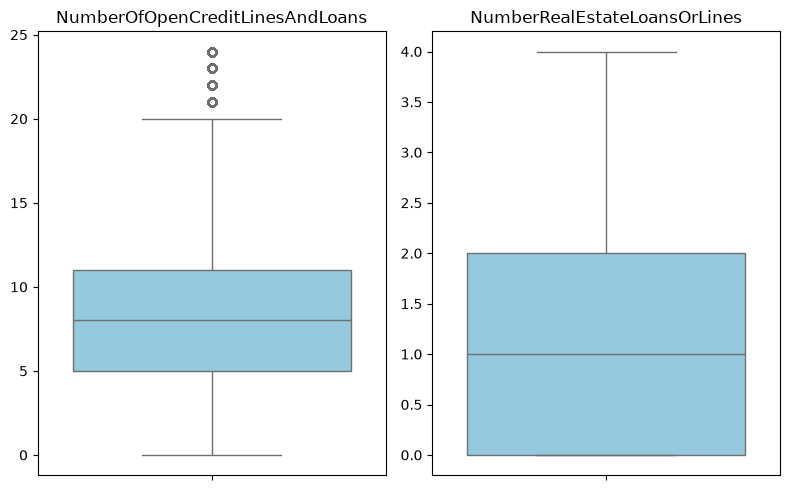

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes = axes.flatten()  

features = ['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']

for i, col in enumerate(features):
    sns.boxplot(data=credit_data, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('') 

plt.tight_layout()
plt.show()

as we can see the features were modified

In [51]:
features = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

for feature in features:
    credit_data[feature] = np.log1p(credit_data[feature])

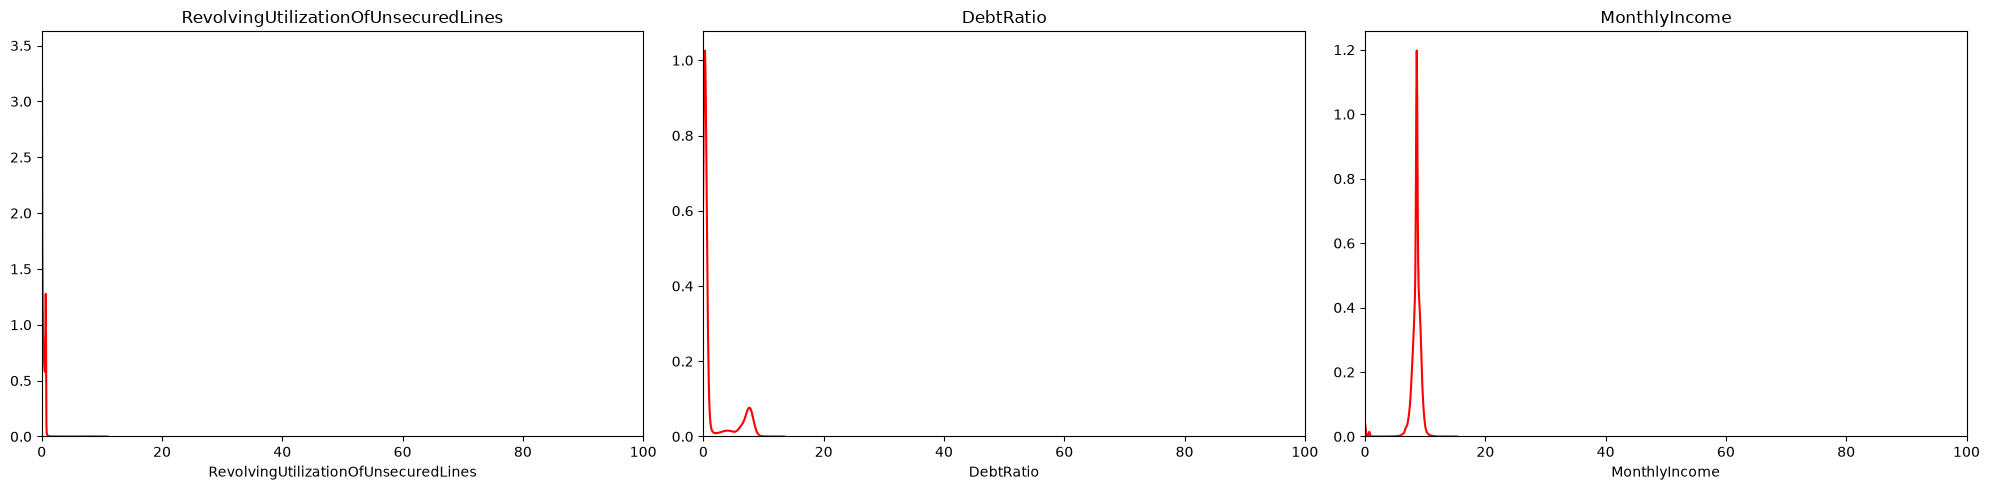

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.flatten()  

# continuous features
features = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

for i, col in enumerate(features):
    sns.kdeplot(data=credit_data, x=col, ax=axes[i], color='red')
    axes[i].set_title(col)
    axes[i].set_ylabel('')

    if col == 'RevolvingUtilizationOfUnsecuredLines':
        axes[i].set_xlim(0, 100)  
    elif col == 'DebtRatio':
        axes[i].set_xlim(0, 100)  
    elif col == 'MonthlyIncome':
        axes[i].set_xlim(0, 100) 


plt.tight_layout()
plt.show()

the range of the values has changed and density functions also have changed after applying log function